# 02 — TXS 0506+056: the Fermi-LAT counterpart to IceCube-170922A

On 2017-09-22 IceCube reported a 290 TeV neutrino — **IC-170922A** — whose 90 % containment region landed on top of the BL Lac **TXS 0506+056** ([4FGL J0509.4+0542](https://fermi.gsfc.nasa.gov/cgi-bin/ssc/LAT/14yr_catalog/source.cgi?source=J0509.4+0542), z = 0.3365). The follow-up Fermi-LAT analysis [IceCube et al. 2018, *Science* 361, eaat1378](https://www.science.org/doi/10.1126/science.aat1378) showed the source in a **6-month γ-ray flare** at the time of the alert — the first compelling extragalactic neutrino source identification.

This notebook redoes the LAT side of that analysis end-to-end:

| | |
|---|---|
| Centre | (RA, Dec) = (77.3582°, +5.69315°) |
| ROI radius (data) | 15° |
| Time window | MET 494 380 804 → 557 452 805  (2016-09-01 → 2018-09-01, alert at the centre) |
| Energy | 100 MeV – 300 GeV |
| Catalog | 4FGL (DR4) |

Compared to notebook 01 (PG 1553+113) the analysis is intentionally **streamlined**: setup → fit → SED → **lightcurve**. The lightcurve is the headline result — it shows the 2017 flare.


## Why TXS 0506+056 is *harder* than PG 1553+113

Two sources, almost identical analysis recipe — but TXS is meaningfully harder. Three reasons matter, and they all stem from where the source sits on the sky and how it varies in time.

### 1. Galactic latitude

| Source | Galactic (l, b) | csc \|b\| (rough diffuse-brightness proxy) |
|---|---|---|
| PG 1553+113 | (21.9°,  +44.0°) | 1.44 |
| **TXS 0506+056** | (195.4°, **−19.6°**) | **2.97** |

TXS sits ~24° closer to the Galactic plane than PG 1553. The Galactic diffuse emission (`gll_iem_v07.fits`) scales roughly as csc \|b\| at moderate latitudes, so the diffuse background under TXS is **~2× brighter** than under PG 1553 — and, worse, it has a **strong gradient across the 10°×10° fit ROI** because the low-b edge of the ROI sits at b ≈ −5°, only 5° from the plane. Any mis-modelling of that gradient masquerades as flux from the target.

Mitigation: we keep the diffuse normalisation free in the fit and use a *larger* model ROI (15°) than fit ROI (10°) so PSF tails of off-ROI sources are still represented.

### 2. Source crowding & PSF-mixing at low energy

TXS lies toward the Galactic anti-centre (l ≈ 195°), so the inner-Galaxy diffuse component is suppressed — but it's still in a busier 4FGL neighbourhood than PG 1553. The LAT PSF at 100 MeV is ~3–5°, larger than the typical separation of catalog sources in this field. Below ~300 MeV, every photon's source assignment is statistical, and a poorly-fit neighbour will leak counts into the target.

Mitigation: free spectral *normalis\zations* of all sources within 3° of the centre; keep their *shapes* fixed at the 4FGL values.

### 3. Variability

TXS is a **flaring blazar**. The 2-year window we are fitting straddles a months-long flare around the IceCube alert. A single-state spectral fit averages a quiescent ~10⁻⁸ ph cm⁻² s⁻¹ baseline with a flare ~5–10× brighter, so:

- the LogParabola curvature parameter β tries to compensate for two states with one curve and ends up poorly determined;
- the average spectrum is **not** the spectrum *during* the flare. To see the flare we have to do a **lightcurve** — which is the last section.

### 4. EBL (worth knowing, ignored here)

At z = 0.3365 the EBL optical depth τ_γγ reaches ≈1 around 150–200 GeV, so the topmost bin (300 GeV) is already attenuated. We fit the *observed* spectrum and don't correct for EBL — just remember that the highest-energy bin is biased low. (For a proper intrinsic-SED measurement you'd attach an EBL absorption model to the source spectrum.)


## Setup

Same conventions as notebook 01: working directory under `data/txs0506/`, `FERMI_DIFFUSE_DIR` pointed at the diffuse files inside the conda env.


In [10]:
import os
from pathlib import Path

ANADIR = Path("/Users/mcrnogor/Library/CloudStorage/Dropbox/"
              "lectures/fermipy/lecture/data/txs0506")

os.environ['FERMI_DIFFUSE_DIR'] = (
    "/Users/mcrnogor/miniconda3/envs/fermipy/share/"
    "fermitools/refdata/fermi/galdiffuse"
)

os.chdir(ANADIR)
print("working in:", os.getcwd())
print("\ncontents:")
for p in sorted(ANADIR.iterdir()):
    print(f"  {p.name}")


working in: /Users/mcrnogor/Library/CloudStorage/Dropbox/lectures/fermipy/lecture/data/txs0506

contents:
  4fgl_j0509.4+0542_sed.fits
  4fgl_j0509.4+0542_sed.npy
  L2605041500386812327D77_PH00.fits
  L2605041500386812327D77_PH01.fits
  L2605041500386812327D77_PH02.fits
  L2605041500386812327D77_PH03.fits
  L2605041500386812327D77_PH04.fits
  L2605041500386812327D77_PH05.fits
  L2605041500386812327D77_PH06.fits
  L2605041500386812327D77_SC00.fits
  bexpmap_00.fits
  bexpmap_roi_00.fits
  ccube.fits
  ccube_00.fits
  config.yaml
  evfile_00.txt
  fermipy.log
  fit_txs.fits
  fit_txs.npy
  fit_txs_00.xml
  fit_txs_counts_map_2.000_5.477.png
  fit_txs_counts_map_xproj_2.000_5.477.png
  fit_txs_counts_map_yproj_2.000_5.477.png
  fit_txs_counts_spectrum.png
  fit_txs_model_map_2.000_5.477.png
  ft1.txt
  ft1_00.fits
  ft2.txt
  gtbin.par
  gtexpcube2.par
  gtltcube.par
  gtselect.par
  gtsrcmaps.par
  ltcube_00.fits
  scfile_00.txt
  srcmap_00.fits
  srcmdl_00.xml


The pre-written `ft1.txt`, `ft2.txt`, `config.yaml` are the only things this notebook *needs* on disk; everything else (`*_00.fits`, `srcmap_00.fits`, `ltcube_00.fits`, …) will be created by `gta.setup()` and re-used on subsequent runs.


In [11]:
print("=== ft1.txt ===")
print(open("ft1.txt").read())
print("=== ft2.txt ===")
print(open("ft2.txt").read())
print("=== config.yaml ===")
print(open("config.yaml").read())


=== ft1.txt ===
L2605041500386812327D77_PH00.fits
L2605041500386812327D77_PH01.fits
L2605041500386812327D77_PH02.fits
L2605041500386812327D77_PH03.fits
L2605041500386812327D77_PH04.fits
L2605041500386812327D77_PH05.fits
L2605041500386812327D77_PH06.fits

=== ft2.txt ===
L2605041500386812327D77_SC00.fits

=== config.yaml ===
data:
  evfile : ft1.txt
  scfile : ft2.txt
  ltcube  : ltcube_00.fits


binning:
  roiwidth   : 10.0
  binsz      : 0.1
  binsperdec : 8

selection :
  emin : 100
  emax : 300000
  tmin: 494380804
  tmax: 557452805
  zmax    : 90
  evclass : 128
  evtype  : 3
  target : '4FGL J0509.4+0542'

gtlike:
  edisp : True
  irfs : 'P8R3_SOURCE_V3'

model:
  src_roiwidth : 15.0
  galdiff  : '$FERMI_DIFFUSE_DIR/gll_iem_v07.fits'
  isodiff  : '$FERMI_DIFFUSE_DIR/iso_P8R3_SOURCE_V3_v1.txt'
  catalogs :
    - '4FGL'



## Run the analysis chain

`gta.setup()` will run `gtselect → gtmktime → gtltcube → gtbin → gtexpcube2 → gtsrcmaps`. With 2 years of data over a 15° ROI, expect **~15-30 min** the *first* time (dominated by `gtltcube` and `gtsrcmaps`). Re-runs find the cached files and finish in seconds.


In [12]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

from fermipy.gtanalysis import GTAnalysis
gta = GTAnalysis("config.yaml", logging={"verbosity": 3})
gta.setup()


2026-05-04 22:08:29 INFO    GTAnalysis.__init__(): 
--------------------------------------------------------------------------------
fermipy version 1.4.0 
ScienceTools version 2.2.0
2026-05-04 22:08:29 INFO    GTAnalysis.setup(): Running setup.
2026-05-04 22:08:29 INFO    GTBinnedAnalysis.setup(): Running setup for component 00
2026-05-04 22:08:29 INFO    GTBinnedAnalysis._select_data(): Skipping data selection.
2026-05-04 22:08:29 INFO    GTBinnedAnalysis.setup(): Using external LT cube.
2026-05-04 22:08:29 INFO    GTBinnedAnalysis._create_expcube(): Skipping gtexpcube.
the RADECSYS keyword is deprecated, use RADESYSa. [astropy.wcs.wcs]
Set MJD-OBS to 57632.000000 from DATE-OBS.
Set MJD-END to 58362.000000 from DATE-END'. [astropy.wcs.wcs]
2026-05-04 22:08:29 INFO    GTBinnedAnalysis._create_srcmaps(): Skipping gtsrcmaps.
2026-05-04 22:08:29 INFO    GTBinnedAnalysis.setup(): Finished setup for component 00
2026-05-04 22:08:29 INFO    GTBinnedAnalysis._create_binned_analysis(): Creati

### ROI inventory

`print_roi()` after `setup()` lists every source fermipy has loaded into the model. Note the difference from PG 1553's ROI: **more catalog sources at small offset**, and the diffuse `npred` (counts predicted from `gll_iem_v07`) is dramatically larger because of the lower latitude — that's the diffuse-domination effect from §2.1 made concrete.


In [13]:
gta.print_roi()
print()
print(gta.roi['4FGL J0509.4+0542'])


2026-05-04 22:08:36 INFO    GTAnalysis.print_roi(): 
name                SpatialModel   SpectrumType     offset        ts       npred
--------------------------------------------------------------------------------
4FGL J0509.4+0542   PointSource    LogParabola       0.000       nan      2058.9
4FGL J0505.3+0459   PointSource    LogParabola       1.231       nan      3921.6
4FGL J0505.6+0415   PointSource    PowerLaw          1.722       nan       170.6
4FGL J0502.4+0609   PointSource    PowerLaw          1.792       nan       456.5
4FGL J0506.9+0323   PointSource    PowerLaw          2.393       nan        98.1
4FGL J0457.0+0646   PointSource    PowerLaw          3.270       nan       330.6
4FGL J0517.5+0858   PointSource    PowerLaw          3.849       nan       129.7
4FGL J0519.0+0851   PointSource    PowerLaw          3.966       nan       608.2
4FGL J0509.4+1012   PointSource    PowerLaw          4.499       nan       371.7
4FGL J0521.6+0103   PointSource    PowerLaw          5.5


Name           : 4FGL J0509.4+0542
Associations   : ['4FGL J0509.4+0542', 'TXS 0506+056']
RA/DEC         :     77.359/     5.701
GLON/GLAT      :    195.399/   -19.631
TS             : nan
Npred          : 2058.89
Flux           : 5.457e-08 +/-      nan
EnergyFlux     : 3.776e-05 +/-      nan
SpatialModel   : PointSource
SpectrumType   : LogParabola
Spectral Parameters
b'norm'        :  5.062e-12 +/-        nan
b'alpha'       :       1.99 +/-        nan
b'beta'        :     0.0513 +/-        nan
b'Eb'          :       1126 +/-        nan


### Visual: the diffuse gradient

A quick counts-map summed over energy makes the latitude effect obvious — the southern (low-b) edge of the ROI is brighter than the northern edge before any source modelling.


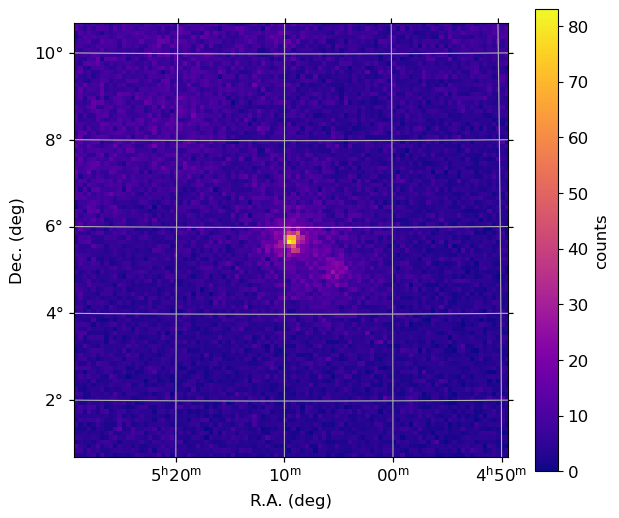

In [14]:
from astropy.io import fits
from astropy.wcs import WCS

h = fits.open('ccube.fits')
wcs = WCS(h[0].header).dropaxis(-1)
counts = h[0].data

fig, ax = plt.subplots(subplot_kw={'projection': wcs}, figsize=(7, 6))
im = ax.imshow(np.sum(counts, axis=0), origin='lower',
               cmap='plasma', interpolation='nearest')
plt.colorbar(im, ax=ax, label='counts')
ax.set_xlabel('R.A. (deg)'); ax.set_ylabel('Dec. (deg)')
ax.grid()
plt.show()


## Likelihood fit

Same recipe as PG 1553:

1. Fix everything,
2. Free *normalisations* of sources within 3° of the centre,
3. Free the diffuse normalisations,
4. Free the **full spectral shape** of TXS (LogParabola: norm, α, β),
5. Fit.


In [15]:
gta.free_sources(free=False)
gta.free_sources(distance=3.0, pars='norm')
gta.free_source('galdiff', pars='norm')
gta.free_source('isodiff')
gta.free_source('4FGL J0509.4+0542')

fit = gta.fit()
print('fit_quality:', fit['fit_quality'])
print(gta.roi['4FGL J0509.4+0542'])

gta.write_roi('fit_txs', make_plots=True)


2026-05-04 22:08:39 INFO    GTAnalysis.free_source(): Freeing parameters for 4FGL J0509.4+0542     : ['norm']
2026-05-04 22:08:39 INFO    GTAnalysis.free_source(): Freeing parameters for 4FGL J0505.3+0459     : ['norm']
2026-05-04 22:08:39 INFO    GTAnalysis.free_source(): Freeing parameters for 4FGL J0505.6+0415     : ['Prefactor']
2026-05-04 22:08:39 INFO    GTAnalysis.free_source(): Freeing parameters for 4FGL J0502.4+0609     : ['Prefactor']
2026-05-04 22:08:39 INFO    GTAnalysis.free_source(): Freeing parameters for 4FGL J0506.9+0323     : ['Prefactor']
2026-05-04 22:08:39 INFO    GTAnalysis.free_source(): Freeing parameters for isodiff               : ['Normalization']
2026-05-04 22:08:39 INFO    GTAnalysis.free_source(): Freeing parameters for galdiff               : ['Prefactor']
2026-05-04 22:08:39 INFO    GTAnalysis.free_source(): Freeing parameters for 4FGL J0509.4+0542     : ['alpha', 'beta']
2026-05-04 22:08:39 INFO    GTAnalysis.fit(): Starting fit.
/Users/mcrnogor/minico

fit_quality: 3
Name           : 4FGL J0509.4+0542
Associations   : ['4FGL J0509.4+0542', 'TXS 0506+056']
RA/DEC         :     77.359/     5.701
GLON/GLAT      :    195.399/   -19.631
TS             : 6570.95
Npred          : 6186.15
Flux           : 1.667e-07 +/- 6.75e-09
EnergyFlux     : 0.0001039 +/- 4.39e-06
SpatialModel   : PointSource
SpectrumType   : LogParabola
Spectral Parameters
b'norm'        :  1.473e-11 +/-  4.035e-13
b'alpha'       :      2.033 +/-       0.02
b'beta'        :    0.05541 +/-     0.0112
b'Eb'          :       1126 +/-        nan


2026-05-04 22:08:45 INFO    GTAnalysis.write_roi(): Writing /Users/mcrnogor/Library/CloudStorage/Dropbox/lectures/fermipy/lecture/data/txs0506/fit_txs.npy...


## SED — average over the 2-year window

Bowtie (covariance-propagated 1σ band) and binned-likelihood points. We use `cov_scale=None` and `use_local_index=True` to keep the per-bin profile likelihood numerically stable — without these flags the LogParabola scan can produce NaN log-likelihoods and `gta.sed` raises (we hit this on PG 1553).

Reloading the saved ROI before the SED guarantees we start from the converged fit, not from any drifted state left over from re-runs.


In [17]:
gta.load_roi('fit_txs')
sed = gta.sed('4FGL J0509.4+0542')


2026-05-04 22:08:59 INFO    GTAnalysis.load_roi(): Loading ROI file: /Users/mcrnogor/Library/CloudStorage/Dropbox/lectures/fermipy/lecture/data/txs0506/fit_txs.npy


2026-05-04 22:08:59 INFO    GTBinnedAnalysis._create_binned_analysis(): Creating BinnedAnalysis for component 00.
2026-05-04 22:09:04 INFO    GTAnalysis.load_roi(): Finished Loading ROI
2026-05-04 22:09:04 INFO    GTAnalysis.sed(): Computing SED for 4FGL J0509.4+0542
2026-05-04 22:09:04 INFO    GTAnalysis._make_sed(): Fitting SED
2026-05-04 22:09:04 INFO    GTAnalysis.free_source(): Fixing parameters for 4FGL J0509.4+0542     : ['alpha', 'beta']
2026-05-04 22:09:11 INFO    GTAnalysis.sed(): Finished SED
2026-05-04 22:09:14 INFO    GTAnalysis.sed(): Execution time: 10.14 s


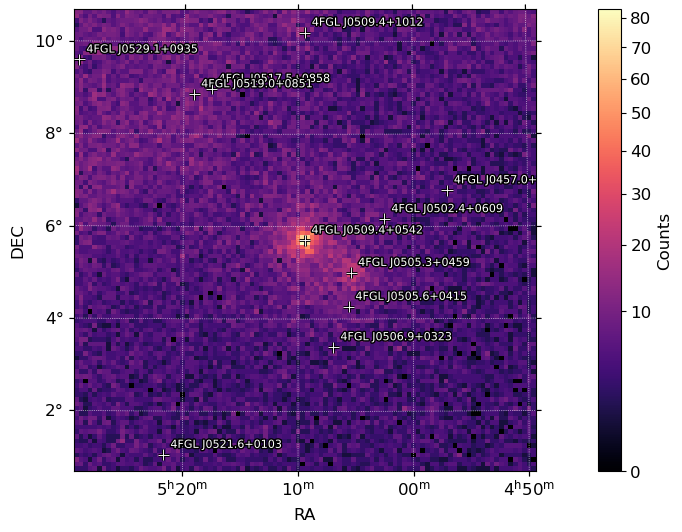

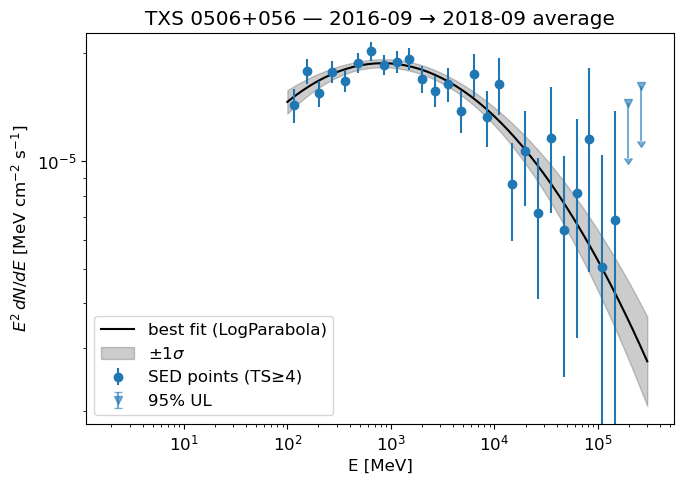

In [18]:
# Bowtie from the global fit
c       = np.load('fit_txs.npy', allow_pickle=True).flat[0]
mflux   = c['sources']['4FGL J0509.4+0542']['model_flux']
E       = np.array(mflux['energies'])
dnde    = np.array(mflux['dnde'])
dnde_hi = np.array(mflux['dnde_hi'])
dnde_lo = np.array(mflux['dnde_lo'])

fig, ax = plt.subplots(figsize=(7, 5))
ax.set_xscale('log'); ax.set_yscale('log')
ax.plot(E, E**2 * dnde, 'k-', lw=1.5, label='best fit (LogParabola)')
ax.fill_between(E, E**2 * dnde_lo, E**2 * dnde_hi,
                color='k', alpha=0.2, label=r'$\pm 1\sigma$')

# SED points: detections (TS >= 4) and 95% ULs otherwise
e_ctr  = np.array(sed['e_ctr'])
e2dnde = np.array(sed['e2dnde'])
e2err  = np.array(sed['e2dnde_err'])
e2ul   = np.array(sed['e2dnde_ul95'])
det    = np.array(sed['ts']) >= 4

ax.errorbar(e_ctr[det], e2dnde[det], yerr=e2err[det],
            fmt='o', color='C0', label='SED points (TS≥4)')
ax.errorbar(e_ctr[~det], e2ul[~det], yerr=0.3*e2ul[~det],
            uplims=True, fmt='v', color='C0', alpha=0.6, label='95% UL')

ax.set_xlabel('E [MeV]')
ax.set_ylabel(r'$E^2\,dN/dE$ [MeV cm$^{-2}$ s$^{-1}$]')
ax.set_title('TXS 0506+056 — 2016-09 → 2018-09 average')
ax.legend()
fig.tight_layout()
plt.show()


## Lightcurve around IC-170922A

This is the headline. We bin the 2-year window into **monthly slices** (~30 d) and re-fit TXS's normalisation in each bin (everything else fixed at the global best-fit).

24 bins × one fit each — and **sequential**, not parallel: on macOS, `multithread=True` triggers a circular-import crash in fermipy's spawn-based pool (`fermipy.lightcurve` ↔ `fermipy.gtanalysis`). Sequential takes ~30-45 min the first time; subsequent runs reuse the per-bin source maps and are much faster.

`gta.lightcurve` does the bookkeeping for you: per-bin `gtbin`/`gtsrcmaps` if needed, per-bin fit, per-bin TS, flux, error, upper limit.


In [20]:
binsize_days = 30.0
tneutrino    = 527806473.0   # MET for 2017-09-22T20:54:30 UTC (IC-170922A)
tmin, tmax   = 494380804, 557452805

edges     = np.arange(tmin, tmax + 1, binsize_days * 86400.)
time_bins = np.column_stack([edges[:-1], edges[1:]])
print(f"{len(time_bins)} bins of ~{binsize_days:.0f} days")

# multithread=False: macOS Python 3.9+ uses 'spawn' for multiprocessing,
# which trips a circular import in fermipy.lightcurve <-> fermipy.gtanalysis.
# Sequential is slower (~30-45 min for 24 bins) but works.
lc = gta.lightcurve('4FGL J0509.4+0542',
                    free_params=['Prefactor'],
                    time_bins=edges.tolist(),
                    multithread=False,
                    save_bin_data=False)


2026-05-04 22:11:05 INFO    GTAnalysis.lightcurve(): Computing Lightcurve for 4FGL J0509.4+0542


24 bins of ~30 days


2026-05-04 22:11:06 INFO    lightcurve_494380804_496972804 GTAnalysis._process_lc_bin(): Fitting time range 494380804 496972804
2026-05-04 22:11:06 INFO    lightcurve_494380804_496972804 GTBinnedAnalysis._create_ltcube(): Generating local LT cube.
the RADECSYS keyword is deprecated, use RADESYSa. [astropy.wcs.wcs]
2026-05-04 22:12:05 INFO    lightcurve_494380804_496972804 GTBinnedAnalysis.write_xml(): Writing /Users/mcrnogor/Library/CloudStorage/Dropbox/lectures/fermipy/lecture/data/txs0506/lightcurve_494380804_496972804/base_00.xml...


Joint fit  ['4FGL J0509.4+0542', '4FGL J0505.3+0459', '4FGL J0532.6+0732']
Fitting shape 4FGL J0509.4+0542 TS:    174.496
Fitting shape 4FGL J0505.3+0459 TS:    152.148
Fitting shape 4FGL J0509.4+1012 TS:     40.931


2026-05-04 22:12:11 INFO    lightcurve_494380804_496972804 GTBinnedAnalysis.write_xml(): Writing /Users/mcrnogor/Library/CloudStorage/Dropbox/lectures/fermipy/lecture/data/txs0506/lightcurve_494380804_496972804/fit_model_final_00.xml...
2026-05-04 22:12:12 INFO    lightcurve_494380804_496972804 GTAnalysis._process_lc_bin(): Finished time range 494380804 496972804
2026-05-04 22:12:13 INFO    lightcurve_496972804_499564804 GTAnalysis._process_lc_bin(): Fitting time range 496972804 499564804
2026-05-04 22:12:13 INFO    lightcurve_496972804_499564804 GTBinnedAnalysis._create_ltcube(): Generating local LT cube.
the RADECSYS keyword is deprecated, use RADESYSa. [astropy.wcs.wcs]
2026-05-04 22:13:12 INFO    lightcurve_496972804_499564804 GTBinnedAnalysis.write_xml(): Writing /Users/mcrnogor/Library/CloudStorage/Dropbox/lectures/fermipy/lecture/data/txs0506/lightcurve_496972804_499564804/base_00.xml...


...

/Users/mcrnogor/miniconda3/envs/fermipy/lib/python3.9/site-packages/fermipy/utils.py:785: UserWarning: 
The maximal number of iterations maxit (set to 20 by the program)
allowed for finding a smoothing spline with fp=s has been reached: s
too small.
There is an approximation returned but the corresponding weighted sum
of squared residuals does not satisfy the condition abs(fp-s)/s < tol.
  spline = UnivariateSpline(x, y, k=2,
2026-05-04 22:35:23 INFO    lightcurve_548812804_551404804 GTBinnedAnalysis.write_xml(): Writing /Users/mcrnogor/Library/CloudStorage/Dropbox/lectures/fermipy/lecture/data/txs0506/lightcurve_548812804_551404804/fit_model_final_00.xml...
2026-05-04 22:35:24 INFO    lightcurve_548812804_551404804 GTAnalysis._process_lc_bin(): Finished time range 548812804 551404804
2026-05-04 22:35:25 INFO    lightcurve_551404804_553996804 GTAnalysis._process_lc_bin(): Fitting time range 551404804 553996804
2026-05-04 22:35:25 INFO    lightcurve_551404804_553996804 GTBinnedAnalysis.

Joint fit  ['4FGL J0509.4+0542', '4FGL J0505.3+0459', '4FGL J0532.6+0732']
Fitting shape 4FGL J0509.4+0542 TS:     90.727
Fitting shape 4FGL J0505.3+0459 TS:     39.877


2026-05-04 22:36:30 INFO    lightcurve_551404804_553996804 GTBinnedAnalysis.write_xml(): Writing /Users/mcrnogor/Library/CloudStorage/Dropbox/lectures/fermipy/lecture/data/txs0506/lightcurve_551404804_553996804/fit_model_final_00.xml...
2026-05-04 22:36:31 INFO    lightcurve_551404804_553996804 GTAnalysis._process_lc_bin(): Finished time range 551404804 553996804
2026-05-04 22:36:32 INFO    lightcurve_553996804_556588804 GTAnalysis._process_lc_bin(): Fitting time range 553996804 556588804
2026-05-04 22:36:32 INFO    lightcurve_553996804_556588804 GTBinnedAnalysis._create_ltcube(): Generating local LT cube.
the RADECSYS keyword is deprecated, use RADESYSa. [astropy.wcs.wcs]
2026-05-04 22:37:31 INFO    lightcurve_553996804_556588804 GTBinnedAnalysis.write_xml(): Writing /Users/mcrnogor/Library/CloudStorage/Dropbox/lectures/fermipy/lecture/data/txs0506/lightcurve_553996804_556588804/base_00.xml...


Joint fit  ['4FGL J0509.4+0542', '4FGL J0505.3+0459', '4FGL J0532.6+0732']
Fitting shape 4FGL J0509.4+0542 TS:    183.058


2026-05-04 22:37:37 INFO    lightcurve_553996804_556588804 GTBinnedAnalysis.write_xml(): Writing /Users/mcrnogor/Library/CloudStorage/Dropbox/lectures/fermipy/lecture/data/txs0506/lightcurve_553996804_556588804/fit_model_final_00.xml...
2026-05-04 22:37:37 INFO    lightcurve_553996804_556588804 GTAnalysis._process_lc_bin(): Finished time range 553996804 556588804
2026-05-04 22:37:39 INFO    GTAnalysis.lightcurve(): Finished Lightcurve


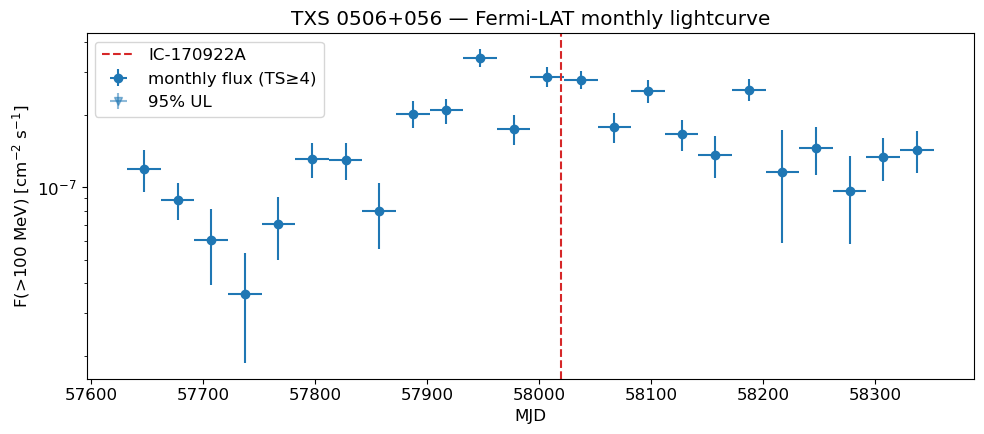

In [21]:
from astropy.time import Time

tmean = 0.5 * (np.asarray(lc['tmin']) + np.asarray(lc['tmax']))
flux  = np.asarray(lc['flux'])
ferr  = np.asarray(lc['flux_err'])
ts    = np.asarray(lc['ts'])
ful   = np.asarray(lc['flux_ul95'])
det   = ts >= 4

# MET → ISO for a readable x-axis (Fermi MET epoch: 2001-01-01 00:00:00 TT)
def met_to_mjd(met):
    return 51910.0 + (met + 64.184) / 86400.0   # rough; ok for plotting
mjd  = met_to_mjd(tmean)
mjd_n = met_to_mjd(tneutrino)

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.errorbar(mjd[det], flux[det], yerr=ferr[det],
            xerr=binsize_days/2, fmt='o', color='C0',
            label='monthly flux (TS≥4)')
ax.errorbar(mjd[~det], ful[~det], yerr=0.3*ful[~det],
            xerr=binsize_days/2, uplims=True, fmt='v', color='C0',
            alpha=0.5, label='95% UL')

ax.axvline(mjd_n, color='C3', ls='--', lw=1.5, label='IC-170922A')
ax.set_yscale('log')
ax.set_xlabel('MJD')
ax.set_ylabel(r'F(>100 MeV) [cm$^{-2}$ s$^{-1}$]')
ax.set_title('TXS 0506+056 — Fermi-LAT monthly lightcurve')
ax.legend(loc='upper left')
fig.tight_layout()
plt.show()


The bin containing **2017-09-22** (and the few months around it) sits well above the rest — the ~6-month enhancement reported in the *Science* 361 paper. The pre-flare and post-flare bins are consistent with a quiescent baseline; many of them are upper limits at this binning.

### What you would do next

- **Finer binning** over the flare window (weekly or daily) to constrain the variability time-scale and feed it into a size argument for the emitting region (R ≲ c · t_var · δ).
- **Bayesian-block** segmentation to avoid the arbitrary fixed binning.
- **Time-resolved SED** in the flare bin only — that's the spectrum to feed into a multi-wavelength SED fit. (Notebook 03 picks this up in **gammapy**.)
- **EBL absorption** model on the intrinsic spectrum if you care about >100 GeV.

### Why this was non-trivial — recap

- The lower Galactic latitude (b = −19.6°) made the diffuse background ~2× brighter and asymmetric across the ROI — keeping the diffuse normalisation free was essential.
- The source field is busier than at high \|b\|, so the PSF-mixed low-energy bins needed careful neighbour-norm freedom (3°-radius rule).
- The source is variable: the 2-year-averaged SED averages a quiescent state with a 6-month flare. The lightcurve is what makes the result interpretable.
